In [1]:
from dotenv import load_dotenv
from IPython.display import display, Markdown

#### Define State

In [2]:
from langgraph.graph import MessagesState

In [3]:
class State(MessagesState):
    summary: str

#### Define Nodes

In [4]:
from langchain_google_genai import ChatGoogleGenerativeAI
from langchain_core.messages import SystemMessage, AIMessage, HumanMessage, RemoveMessage
from langchain_core.output_parsers import StrOutputParser

In [5]:
chat = ChatGoogleGenerativeAI(
    model = "gemini-3.1-flash-lite-preview",
    temperature = 0.6,
    max_output_tokens = 100,
    seed = 0
)

In [6]:
def ask_ques(state: State) -> State:    
    ai_msg = "Hi! How can I help you?"
    print("AI: ", ai_msg)

    hum_msg = input(ai_msg)
    print("Human: ", hum_msg)

    return State(messages = [AIMessage(ai_msg), HumanMessage(hum_msg)], summary = state.get("summary", ""))    

In [7]:
def chatbot(state: State) -> State:
    print("Asking Chatbot...")

    sys_msg = f'''
    Here's a quick summary of the conversation so far:
    {state.get("summary", "")}

    Keep this in mind to answer the next question
    '''

    response = chat.invoke([SystemMessage(sys_msg)] + state["messages"])
    display(Markdown(StrOutputParser().invoke(response)))

    return State(messages = [response], summary = state.get("summary", ""))

In [8]:
def ask_more(state: State) -> State:
    print("\n", state, "\n")

    ai_msg = "Would you like to ask another question? (yes/no)"
    print("AI: ", ai_msg)
    
    hum_msg = input(ai_msg)
    print("Human: ", hum_msg)

    return State(messages = [AIMessage(ai_msg), HumanMessage(hum_msg)], summary = state.get("summary", ""))

In [9]:
def summarize_and_delete_messages(state: State) -> State:
    print("Summarizing and deleting message history...")

    sys_msg = f'''
    Update the summary of past conversation by incorporating context from the new conversation.
    
    Previous summary: {state.get("summary", "")}

    Return the updated summary only.
    Do not continue the conversation.
    '''

    new_summary = chat.invoke([SystemMessage(sys_msg)] + state["messages"])

    removed_messages = [RemoveMessage(id = i.id) for i in state["messages"][:]] # remove all messages

    return State(messages = removed_messages, summary = StrOutputParser().invoke(new_summary))

#### Define Routing Function

In [10]:
def routing_fn(state: State) -> str:
    if state["messages"][-1].content == "yes":
        return "yes"

    else:
        return "no"

#### Define Graph

In [11]:
from langgraph.graph import StateGraph

In [12]:
graph = StateGraph(State)

In [13]:
graph.add_node("Ask Question", ask_ques)
graph.add_node("ChatBot", chatbot)
graph.add_node("Ask More", ask_more)
graph.add_node("Summarize & Delete Message History", summarize_and_delete_messages)

graph.add_edge("__start__", "Ask Question")
graph.add_edge("Ask Question", "ChatBot")
graph.add_edge("ChatBot", "Ask More")
graph.add_edge("Summarize & Delete Message History", "Ask Question")

graph.add_conditional_edges(
    source = "Ask More",
    path = routing_fn,
    path_map = {"yes": "Summarize & Delete Message History", "no": "__end__"}
)

In [14]:
graph = graph.compile()

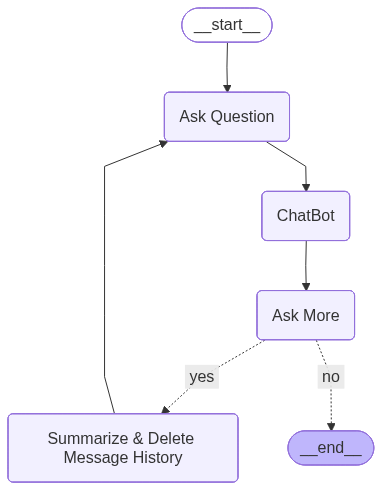

In [15]:
graph

#### Test the graph

In [16]:
graph.invoke(State(messages = [], summary = ""))

AI:  Hi! How can I help you?
Human:  Give me a famous and short poem. Write the poem only.
Asking Chatbot...


The woods are lovely, dark and deep,   
But I have promises to keep,   
And miles to go before I sleep,   
And miles to go before I sleep.


 {'messages': [AIMessage(content='Hi! How can I help you?', additional_kwargs={}, response_metadata={}, id='bc95933a-5edf-4bd4-8e9f-4d39596fe2b5', tool_calls=[], invalid_tool_calls=[]), HumanMessage(content='Give me a famous and short poem. Write the poem only.', additional_kwargs={}, response_metadata={}, id='872c5f50-6dcc-45b2-8555-7522306bc64e'), AIMessage(content=[{'type': 'text', 'text': 'The woods are lovely, dark and deep,   \nBut I have promises to keep,   \nAnd miles to go before I sleep,   \nAnd miles to go before I sleep.', 'extras': {'signature': 'EjQKMgERTTIPkjfF2cSP32F77R/h/AEAwIxdesYG0WYXgGnyPJUPISduMXFgNnL+LedmSr4C'}}], additional_kwargs={}, response_metadata={'finish_reason': 'STOP', 'model_name': 'gemini-3.1-flash-lite', 'safety_ratings': [], 'model_provider': 'google_genai'}, id='lc_run--019f6693-f244-7701-a1ea-838a429a8451-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 52, 'output_tokens': 38, 'total_tokens': 90, 'input_token_details': {'

The author of "Stopping by Woods on a Snowy Evening" is **Robert Frost**. It was first published in 1923 in his collection titled *New Hampshire*.


 {'messages': [AIMessage(content='Hi! How can I help you?', additional_kwargs={}, response_metadata={}, id='3fa30dea-f7e0-4c37-9ca7-3d8397bdf894', tool_calls=[], invalid_tool_calls=[]), HumanMessage(content='Who is the author of this poem?', additional_kwargs={}, response_metadata={}, id='97894703-cc94-4495-8dab-dd7d71a800e2'), AIMessage(content=[{'type': 'text', 'text': 'The author of "Stopping by Woods on a Snowy Evening" is **Robert Frost**. It was first published in 1923 in his collection titled *New Hampshire*.', 'extras': {'signature': 'EjQKMgERTTIPhBti7aJhrBFTb9ur1Fb05354uPOL9T8gRi+lX6nV/ql6pRGA/XBzrJEfFcxK'}}], additional_kwargs={}, response_metadata={'finish_reason': 'STOP', 'model_name': 'gemini-3.1-flash-lite', 'safety_ratings': [], 'model_provider': 'google_genai'}, id='lc_run--019f6694-2d50-7833-b434-00fbb8692dee-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 85, 'output_tokens': 35, 'total_tokens': 120, 'input_token_details': {'cache_read': 0}}

Robert Frost was born on **March 26, 1874**, in **San Francisco, California**.

It is a common misconception that he was a lifelong New Englander, but he actually lived in San Francisco until he was 11 years old. After his father passed away, his mother moved the family to Lawrence, Massachusetts, which is where he began his long association with the New England landscape that defined much of his poetry.


 {'messages': [AIMessage(content='Hi! How can I help you?', additional_kwargs={}, response_metadata={}, id='5fd12bb7-86ff-4e31-9a86-9ca65ac954ee', tool_calls=[], invalid_tool_calls=[]), HumanMessage(content='When and where was the poet born?', additional_kwargs={}, response_metadata={}, id='39127e29-81f4-4dda-85c5-f2be89c880c2'), AIMessage(content=[{'type': 'text', 'text': 'Robert Frost was born on **March 26, 1874**, in **San Francisco, California**.\n\nIt is a common misconception that he was a lifelong New Englander, but he actually lived in San Francisco until he was 11 years old. After his father passed away, his mother moved the family to Lawrence, Massachusetts, which is where he began his long association with the New England landscape that defined much of his poetry.', 'extras': {'signature': 'EjQKMgERTTIPY67+e0WserBCmkly3GBwfP1pzy1W6n08LrsHdAIIT4F5kksALi59TGCFuek1'}}], additional_kwargs={}, response_metadata={'finish_reason': 'STOP', 'model_name': 'gemini-3.1-flash-lite', 's

Yes, I certainly do! It was **"Stopping by Woods on a Snowy Evening"** by Robert Frost. 

It is famous for its rhythmic, hypnotic quality and that iconic final stanza:

*"The woods are lovely, dark and deep,*
*But I have promises to keep,*
*And miles to go before I sleep,*
*And miles to go before I sleep."*

Would you like to talk more about the meaning behind the poem, or


 {'messages': [AIMessage(content='Hi! How can I help you?', additional_kwargs={}, response_metadata={}, id='46bf954b-96a6-489e-a8c9-5dd6f7443a1d', tool_calls=[], invalid_tool_calls=[]), HumanMessage(content='Do you remember the poem you gave me?', additional_kwargs={}, response_metadata={}, id='3a90c925-3769-471e-93ce-a27453bb42c4'), AIMessage(content=[{'type': 'text', 'text': 'Yes, I certainly do! It was **"Stopping by Woods on a Snowy Evening"** by Robert Frost. \n\nIt is famous for its rhythmic, hypnotic quality and that iconic final stanza:\n\n*"The woods are lovely, dark and deep,*\n*But I have promises to keep,*\n*And miles to go before I sleep,*\n*And miles to go before I sleep."*\n\nWould you like to talk more about the meaning behind the poem, or', 'extras': {'signature': 'EjQKMgERTTIP36RaAIeK3GJUCTyvoa15tmFvoHGllMyBnFOCHIsVWlhmFGm3odr/o8ai3uZN'}}], additional_kwargs={}, response_metadata={'finish_reason': 'MAX_TOKENS', 'model_name': 'gemini-3.1-flash-lite', 'safety_ratings':

{'messages': [AIMessage(content='Hi! How can I help you?', additional_kwargs={}, response_metadata={}, id='46bf954b-96a6-489e-a8c9-5dd6f7443a1d', tool_calls=[], invalid_tool_calls=[]),
  HumanMessage(content='Do you remember the poem you gave me?', additional_kwargs={}, response_metadata={}, id='3a90c925-3769-471e-93ce-a27453bb42c4'),
  AIMessage(content=[{'type': 'text', 'text': 'Yes, I certainly do! It was **"Stopping by Woods on a Snowy Evening"** by Robert Frost. \n\nIt is famous for its rhythmic, hypnotic quality and that iconic final stanza:\n\n*"The woods are lovely, dark and deep,*\n*But I have promises to keep,*\n*And miles to go before I sleep,*\n*And miles to go before I sleep."*\n\nWould you like to talk more about the meaning behind the poem, or', 'extras': {'signature': 'EjQKMgERTTIP36RaAIeK3GJUCTyvoa15tmFvoHGllMyBnFOCHIsVWlhmFGm3odr/o8ai3uZN'}}], additional_kwargs={}, response_metadata={'finish_reason': 'MAX_TOKENS', 'model_name': 'gemini-3.1-flash-lite', 'safety_ratings